In [ ]:
# ===============================
# Case Outcome Prediction Analysis
# Exploratory Data Analysis
# ===============================

# Author: Shelly Resurreccion
# Purpose: Exploratory data analysis of synthetic case outcome data to identify patterns and key predictive features.

# Requirements
# pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# ===============================
# Import libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Set plot style
sns.set(style='whitegrid')

In [ ]:
# =====================================================
# Load the dataset
# =====================================================
data = pd.read_csv('../00_data/synthetic_case_outcomes.csv')
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (500, 11)


,case_id,case_type,court_level,filing_year,num_parties,has_jury,num_legal_reps,duration_days,settled_pre_trial,prior_cases_same_party,outcome
0,1001,family,trial,2020,4,True,2,363,True,1,settled
1,1002,contract,trial,2021,3,False,2,153,False,6,defendant_win
2,1003,civil,trial,2015,3,False,1,143,False,9,defendant_win
3,1004,family,appeal,2015,4,False,1,307,True,3,settled
4,1005,family,trial,2015,4,False,2,242,False,9,plaintiff_win


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   case_id                 500 non-null    int64
 1   case_type               500 non-null    str  
 2   court_level             500 non-null    str  
 3   filing_year             500 non-null    int64
 4   num_parties             500 non-null    int64
 5   has_jury                500 non-null    bool 
 6   num_legal_reps          500 non-null    int64
 7   duration_days           500 non-null    int64
 8   settled_pre_trial       500 non-null    bool 
 9   prior_cases_same_party  500 non-null    int64
 10  outcome                 500 non-null    str  
dtypes: bool(2), int64(6), str(3)
memory usage: 36.3 KB


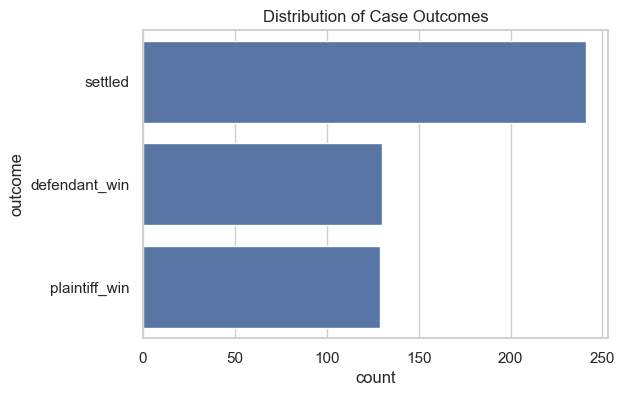

In [ ]:
# =====================================================
# Exploratory Data Analysis (EDA)
# =====================================================
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(data['outcome'])
plt.title('Distribution of Case Outcomes')
plt.show()

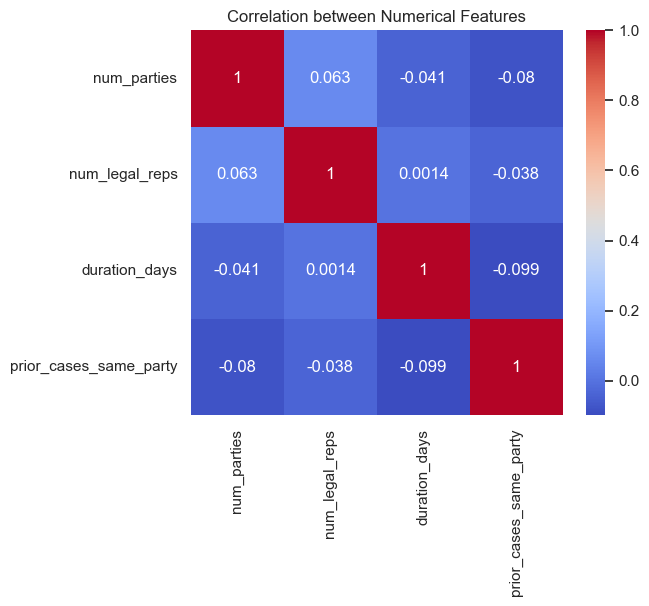

In [17]:
# Correlation heatmap for numerical features
numerical_cols = ['num_parties', 'num_legal_reps', 'duration_days', 'prior_cases_same_party']
plt.figure(figsize=(6,5))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Numerical Features')
plt.show()

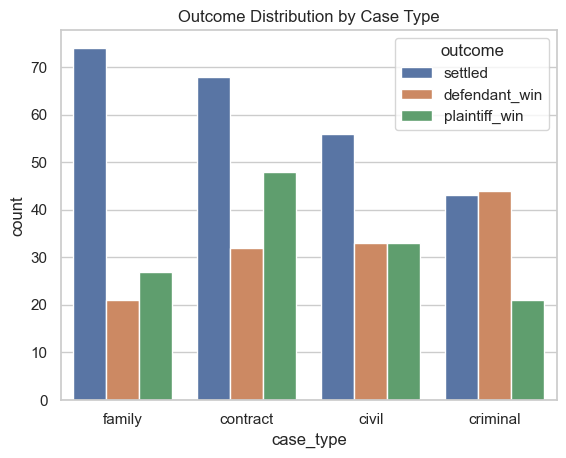

In [19]:
# Target Variable Analysis
sns.countplot(data=data, x='case_type', hue='outcome')
plt.title('Outcome Distribution by Case Type')
plt.show()

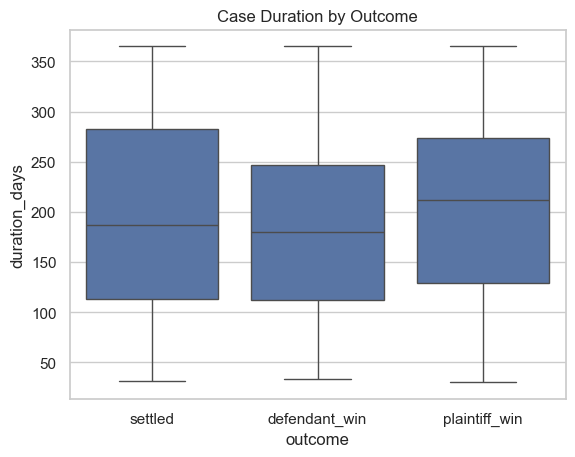

In [20]:
# Numerical Feature Analysis
sns.boxplot(x='outcome', y='duration_days', data=data)
plt.title('Case Duration by Outcome')
plt.show()

In [21]:
# Categorical Feature Analysis
pd.crosstab(data['case_type'], data['outcome'], normalize='index')

outcome,defendant_win,plaintiff_win,settled
case_type,,,
civil,0.270492,0.270492,0.459016
contract,0.216216,0.324324,0.459459
criminal,0.407407,0.194444,0.398148
family,0.172131,0.221311,0.606557


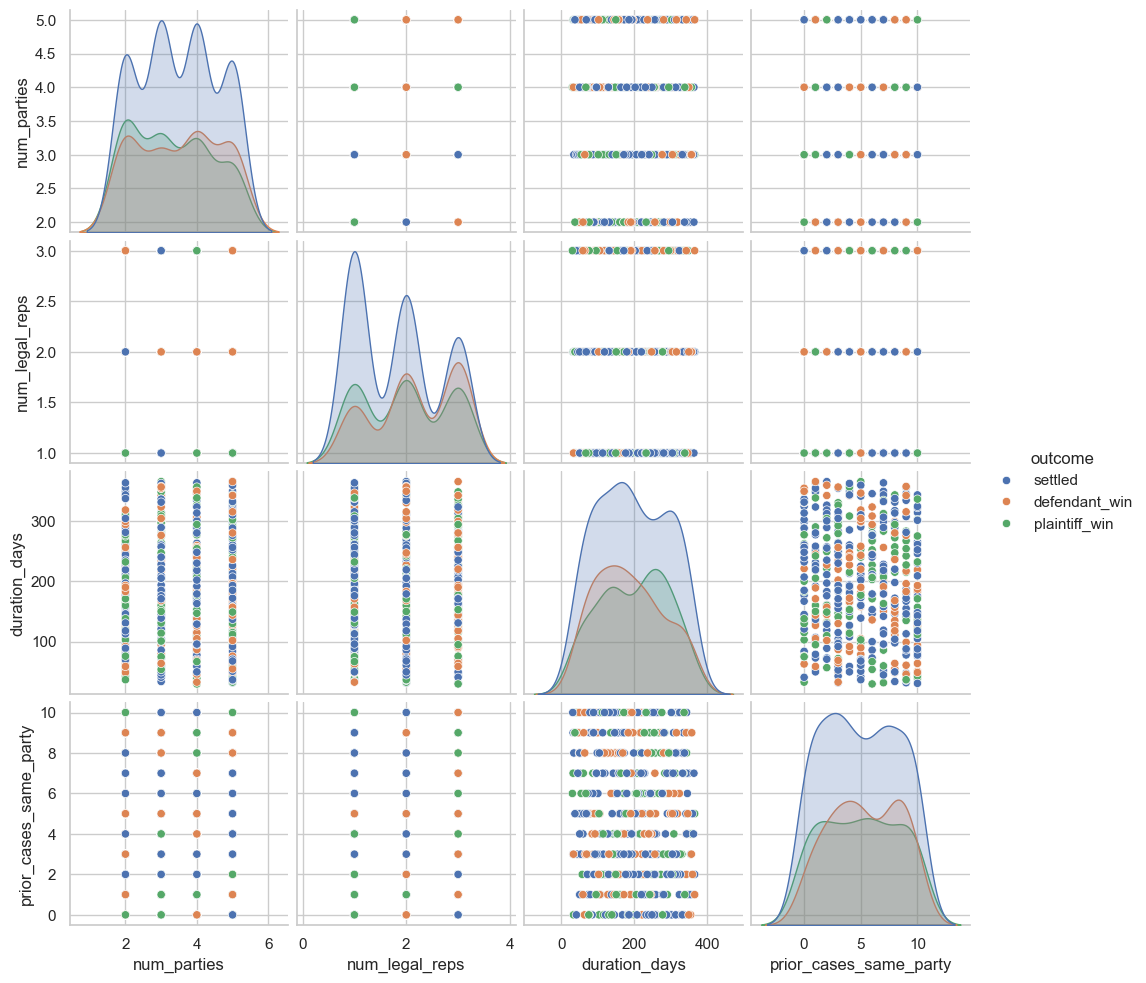

In [22]:
# Relationships Between Features
sns.pairplot(data[numerical_cols + ['outcome']], hue='outcome')

In [23]:
# Feature Interaction Analysis
data.groupby('case_type')['duration_days'].mean()
data.groupby(['case_type','settled_pre_trial'])['duration_days'].mean()

case_type  settled_pre_trial
civil      False                199.653846
           True                 192.659091
contract   False                189.413043
           True                 190.250000
criminal   False                181.892308
           True                 204.627907
family     False                190.701299
           True                 206.022222
Name: duration_days, dtype: float64

In [ ]:
# =====================================================
# Conclusions
# =====================================================